# Tutorial for collision detection module

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import pyshipsim
from pyshipsim import simple_ship_poly, detail_ship_poly, rectangle_ship_poly 
from utils import font_setting

font_setting()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
ImportError: Import of esso_osaka_3m's f2py mpdule failed.
ImportError: Import of takaoki_3m's f2py mpdule failed.
ImportError: Import of pcc_3m's f2py module failed.
ImportError: Import of flap3rd's f2py module failed.


`pyshipsim`には以下の3つの衝突判定モジュールが実装されている。
- `SegmentsIntersectCollisionChecker`：船体ポリゴンと障害物ポリゴンが交差するかどうかで判定する衝突判定モジュール。
- `EnclosingPointCollisionChecker`：障害物ポリゴンに内接する船体ポリゴンの頂点で判定する衝突判定モジュール。
- `StrictCollisionChecker`：上記の2つの判定を併用する衝突判定モジュール。

衝突チェッカーによって結果が微妙に異なる点に注意が必要である。以下では、船ポリゴンと衝突検出方法による結果の違いを示す。

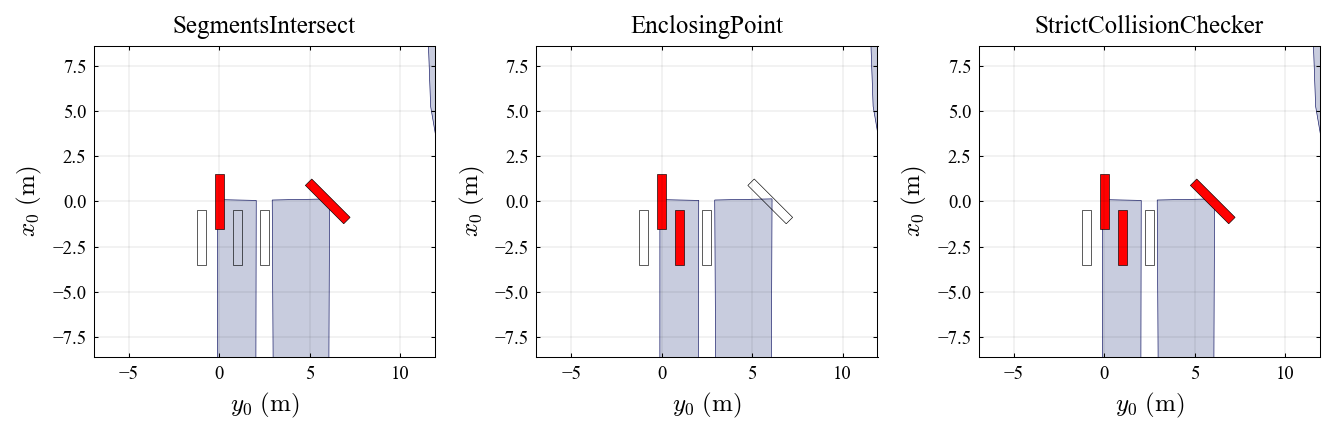

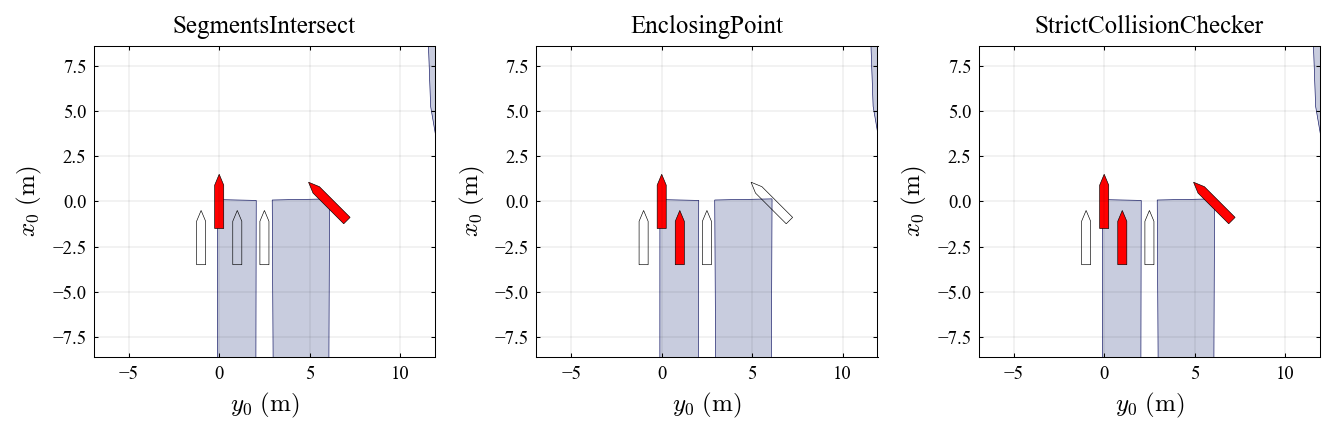

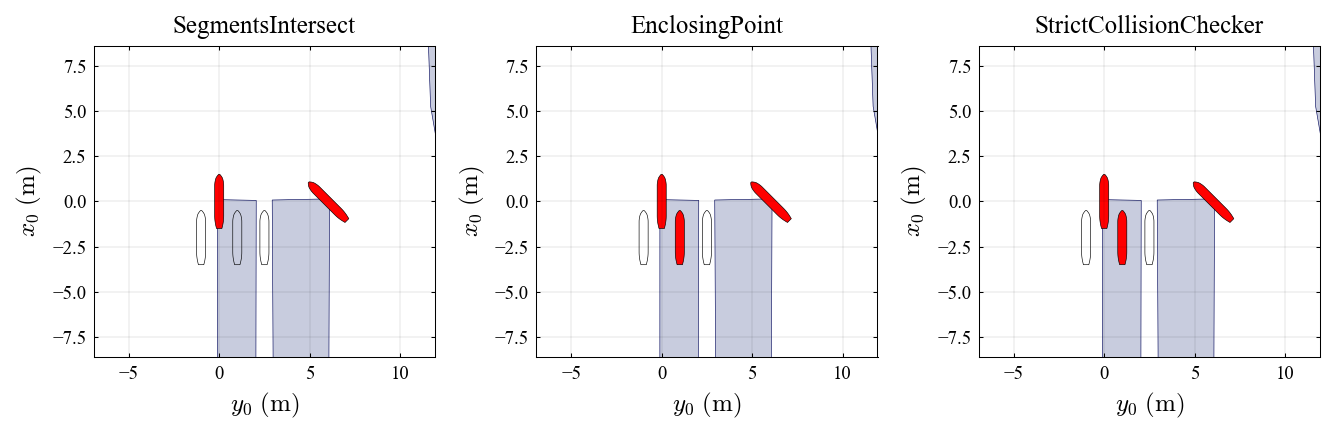

In [2]:
ship_poly_funcs = [
    rectangle_ship_poly,
    simple_ship_poly,
    detail_ship_poly,
]

for ship_poly_func in ship_poly_funcs:
    fig, axes = plt.subplots(1, 3, figsize=(9, 3), tight_layout=True)
    # world
    world_polys = pyshipsim.InukaiPond().polygons
    kwargs = {"fill": True, "lw": 0.3, "fc": "#C8CCDE", "ec": "#0A0F60"}

    def add_poly(ax, polys):
        for poly in polys:
            poly = poly[:, [1, 0]]
            polygon = plt.Polygon(poly, **kwargs)
            ax.add_patch(polygon)

    add_poly(axes[0], world_polys)
    add_poly(axes[1], world_polys)
    add_poly(axes[2], world_polys)

    x_list = [
        np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
        np.array([0.0, 0.0, 6.0, 0.0, -np.pi/4, 0.0]),
        np.array([-2.0, 0.0, 2.5, 0.0, 0.0, 0.0]),
        np.array([-2.0, 0.0, 1.0, 0.0, 0.0, 0.0]),
        np.array([-2.0, 0.0, -1.0, 0.0, 0.0, 0.0]),
    ]
    intersect = pyshipsim.SegmentsIntersectCollisionChecker()
    enclosing = pyshipsim.EnclosingPointCollisionChecker()
    combine = pyshipsim.StrictCollisionChecker()
    for x in x_list:
        ship_poly = ship_poly_func(x, L=3.0, B=0.5)
        # 
        collide = intersect.collide(ship_poly, world_polys)
        kwargs = {"fill": False, "lw": 0.3, "ec": "black"}
        if collide:
            kwargs = {"fill": True, "lw": 0.3, "fc": "red", "ec": "black"}
        add_poly(axes[0], [ship_poly])
        # 
        collide = enclosing.collide(ship_poly, world_polys)
        kwargs = {"fill": False, "lw": 0.3, "ec": "black"}
        if collide:
            kwargs = {"fill": True, "lw": 0.3, "fc": "red", "ec": "black"}
        add_poly(axes[1], [ship_poly])
        # 
        collide = combine.collide(ship_poly, world_polys)
        kwargs = {"fill": False, "lw": 0.3, "ec": "black"}
        if collide:
            kwargs = {"fill": True, "lw": 0.3, "fc": "red", "ec": "black"}
        add_poly(axes[2], [ship_poly])

    axes[0].set_title("SegmentsIntersect")
    axes[1].set_title("EnclosingPoint")
    axes[2].set_title("StrictCollisionChecker")
    axes[0].set_xlabel("$y_{0} \ \mathrm{(m)}$")
    axes[0].set_ylabel("$x_{0} \ \mathrm{(m)}$")
    axes[0].axis("equal")
    axes[1].set_xlabel("$y_{0} \ \mathrm{(m)}$")
    axes[1].set_ylabel("$x_{0} \ \mathrm{(m)}$")
    axes[1].axis("equal")
    axes[2].set_xlabel("$y_{0} \ \mathrm{(m)}$")
    axes[2].set_ylabel("$x_{0} \ \mathrm{(m)}$")
    axes[2].axis("equal")
    axes[0].set_xlim(-5, 10)
    axes[0].set_ylim(-7, 7)
    axes[1].set_xlim(-5, 10)
    axes[1].set_ylim(-7, 7)
    axes[2].set_xlim(-5, 10)
    axes[2].set_ylim(-7, 7)

    path = f"./log/tutorial_collision/{ship_poly_func.__name__}.png"
    if not os.path.exists(os.path.dirname(path)):
            os.makedirs(os.path.dirname(path))
    fig.savefig(path)
